In [1]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.12.0 which is incompatible.
bigframes 1

In [2]:
!pip install fsspec==2024.10.0
!pip install rich==13.7.0  
!pip install pylibraft-cu12==24.12.0 rmm-cu12==24.12.0
!pip install --force-reinstall pylibcugraph-cu12==24.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.6/179.6 kB 138.9 kB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.12.0
    Uninstalling fsspec-2024.12.0:
      Successfully uninstalled fsspec-2024.12.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: rich
    Found existing installation: rich 14.0.0
    Uninstalling rich-14.0.0:
      Successfully uninstalled rich-14.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.2.0 requires toolz<1,>=0.11, but you have toolz 1.0.0 which is incom

In [3]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
raft-dask-cu12 25.2.0 requires pylibraft-cu12==25.2.*, but you have pylibraft-cu12 24.12.0 which is incompatible.
dask-cuda 25.2.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
cuml-cu12 25.2.1 requires cuda-python<13.0a0,>=12.6.2, but you have cuda-python 12.6.0 which is incompatible.
cuml-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
cuml-cu12 25.2.1 requires pylibraft-cu12==25.2.*, but you have pylibraft-cu12 24.12.0 which is

In [4]:
import transformers, datasets, evaluate, accelerate
print("All packages imported successfully")

2025-04-28 01:14:32.053225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745802872.235515      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745802872.289398      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


All packages imported successfully


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding
)
import evaluate
from sklearn.metrics import confusion_matrix, classification_report

# Load Dataset

In [6]:
df = pd.read_csv("/kaggle/input/ag-news-classification-dataset/train.csv")

In [7]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


## Visualize class distribution

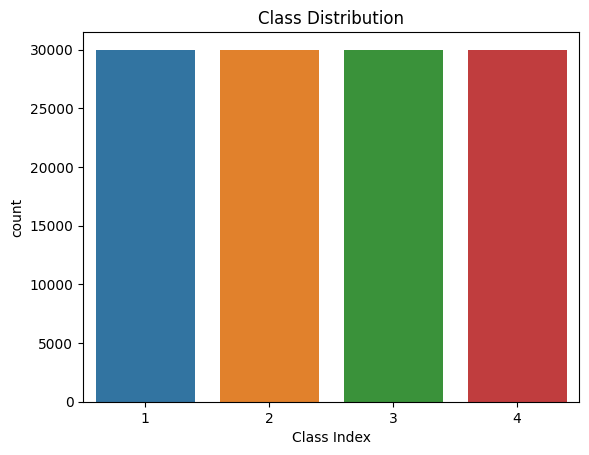

In [8]:
sns.countplot(x=df['Class Index'])
plt.title("Class Distribution")
plt.show()

# Preprocessing 

In [9]:
def preprocess_text(text):
    text = text.lower()# lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)#URLs
    text = re.sub(r'<.*?>', '', text)# HTML tags
    text = re.sub(r'[^\w\s.,!?]', '', text)#special characters and numbers
    return text

In [10]:
df['Cleaned_Text'] = df['Description'].apply(preprocess_text)

In [11]:
print("Original:", df['Description'][0])
print("Preprocessed:", df['Cleaned_Text'][0])

Original: Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Preprocessed: reuters  shortsellers, wall streets dwindlingband of ultracynics, are seeing green again.


## spilt dataset

In [12]:
train, valid = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Class Index'])

In [13]:
train.to_csv('train.csv', index=False)
valid.to_csv('valid.csv', index=False)

In [14]:
dataset = load_dataset('csv', data_files={
    'train': '/kaggle/working/train.csv',
    'valid': '/kaggle/working/valid.csv',
    'test': '/kaggle/input/ag-news-classification-dataset/test.csv'
})

Generating train split: 0 examples [00:00, ? examples/s]

Generating valid split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [15]:
dataset = dataset.rename_columns({
    "Class Index": "label",
    "Cleaned_Text": "text"  # Use the preprocessed text
})

In [16]:
def prepare_dataset(dataset):
    # For each split in the dataset
    for split in dataset.keys():
        # If the split doesn't have 'Cleaned_Text' column, preprocess the 'Description'
        if 'Cleaned_Text' not in dataset[split].features:
            dataset[split] = dataset[split].map(lambda example: {"text": preprocess_text(example["Description"])})
    return dataset

dataset = prepare_dataset(dataset)

Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

## Remove column

In [17]:
if "Title" in dataset["train"].column_names:
    dataset = dataset.remove_columns(["Title"])
if "Description" in dataset["train"].column_names:
    dataset = dataset.remove_columns(["Description"])

In [18]:
# First load the dataset with original labels
dataset = load_dataset('csv', data_files={
    'train': '/kaggle/working/train.csv',
    'valid': '/kaggle/working/valid.csv',
    'test': '/kaggle/input/ag-news-classification-dataset/test.csv'
})

# Check the original labels
print("Original labels:", dataset["train"].unique("Class Index"))

# Rename columns (but don't modify values yet)
dataset = dataset.rename_columns({
    "Class Index": "label",
    "Description": "text"
})

# Now check labels after renaming
print("Labels after renaming:", dataset["train"].unique("label"))

# ONLY IF the labels start from 1, then subtract 1
# First check if they start from 1
label_min = min(dataset["train"].unique("label"))
if label_min == 1:
    # Now adjust labels to be 0-indexed
    dataset = dataset.map(lambda example: {**example, "label": example["label"] - 1})
    print("Labels after adjustment:", dataset["train"].unique("label"))
else:
    print("Labels already start from", label_min, "no adjustment needed")

Original labels: [2, 4, 1, 3]
Labels after renaming: [2, 4, 1, 3]


Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Labels after adjustment: [1, 3, 0, 2]


# GPT

In [19]:
def tokenize_function(examples):
    # GPT-2 has a max length of 1024
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

In [20]:
# Initialize GPT-2 tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# GPT-2 doesn't have a padding token by default, so we need to set it

# Initialize GPT-2 model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    "gpt2",
    num_labels=4,  # 4 classes in AG News dataset
)

# These two lines are essential to fix your error
model.config.pad_token_id = tokenizer.pad_token_id
model.resize_token_embeddings(len(tokenizer))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(50257, 768)

In [21]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [22]:
accuracy = evaluate.load("accuracy")

In [23]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)


In [24]:
training_args = TrainingArguments(
    output_dir="my_gpt2_model",
    learning_rate=5e-5,  # Lower learning rate for GPT-2
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    report_to='none'
)

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["valid"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_19/3990093711.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [26]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.202000,0.185425,0.935792
2,0.148200,0.175613,0.943875
3,0.102500,0.191345,0.943917


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=9000, training_loss=0.17466232130262588, metrics={'train_runtime': 18424.6967, 'train_samples_per_second': 15.631, 'train_steps_per_second': 0.488, 'total_flos': 7.5254823124992e+16, 'train_loss': 0.17466232130262588, 'epoch': 3.0})